In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os


import seaborn as sbn
sbn.set(context='paper', font_scale=0.8, color_codes=True, palette='deep', style='ticks',
        rc={'mathtext.fontset': 'cm', 'axes.linewidth': 1, 'figure.dpi':300, 'figure.figsize':(2,1.5)})

In [2]:
# Let's get organized:
# pickle structure - 
# averagedS_dynamics 

probList = np.linspace(0,1,21).round(2)
rateList1 = [1e-05, 1e-03, 1e-01, 1e+01]
rateList2 = [0.3, 1, 3]
NList=[4, 6, 8, 10]

t_total = 200
dt=5
steps = int(t_total/dt)
rateList = np.logspace(-5,1,4) 

In [3]:
avgedS_dynamics_0 = {}
avgedS_steady_0 = {}

for rate in rateList1:
    
    avgedS_dynamics_0[rate] = {}
    avgedS_steady_0[rate] = {}
    
    for prob in probList:
        
        avgedS_dynamics_0[rate][prob] = {}
        avgedS_steady_0[rate][prob] = {}
                
        with open("RC_avged/avgedS_dynamics_0_p=" + str(prob) + ".pkl", 'rb') as f:
            temp = pickle.load(f)
            
        # N=10 dynamics
        avgedS_dynamics_0[rate][prob] = temp[rate][prob][10]
        

In [4]:
avgedS_dynamics_0 = {}
avgedS_steady_0 = {}

for rate in rateList1:
    
    avgedS_dynamics_0[rate] = {}
    avgedS_steady_0[rate] = {}
    
    for prob in probList:
        
        avgedS_dynamics_0[rate][prob] = {}
        avgedS_steady_0[rate][prob] = {}
                
        with open("RC_avged/avgedS_dynamics_0_p=" + str(prob) + ".pkl", 'rb') as f:
            temp = pickle.load(f)
            
        avgedS_steady_0[rate][prob] = np.zeros(4)

            
        # N=10 dynamics
        avgedS_dynamics_0[rate][prob] = temp[rate][prob][10]
        for (n,N) in enumerate(NList): 
            avgedS_steady_0[rate][prob][n] = np.average(temp[rate][prob][N][steps//2:])
            #print('r=', rate, ' prob=',prob, ' N=', N, 'avg = ', np.average(temp[rate][prob][N][steps//2:]), n)

        

for rate in rateList2:
    
    avgedS_dynamics_0[rate] = {}
    avgedS_steady_0 [rate] = {}
    
    for prob in probList:
        
        avgedS_dynamics_0[rate][prob] = {}
        avgedS_steady_0[rate][prob] = {}
                
        with open("RC_avged/avgedS_dynamics_0_extra_rs_p=" + str(prob) + ".pkl", 'rb') as f:
            temp = pickle.load(f)
            
        # N=10 dynamics
        avgedS_dynamics_0[rate][prob] = temp[rate][prob][10]
        
        avgedS_steady_0[rate][prob] = np.zeros(4)
        
        for (n,N) in enumerate(NList): 
            avgedS_steady_0[rate][prob][n] = np.average(temp[rate][prob][N][steps//2:])
            #print('r=', rate, ' prob=',prob, ' N=', N, 'avg = ', np.average(temp[rate][prob][N][steps//2:]), n)
        #print(avgedS_steady_1[rate][prob])

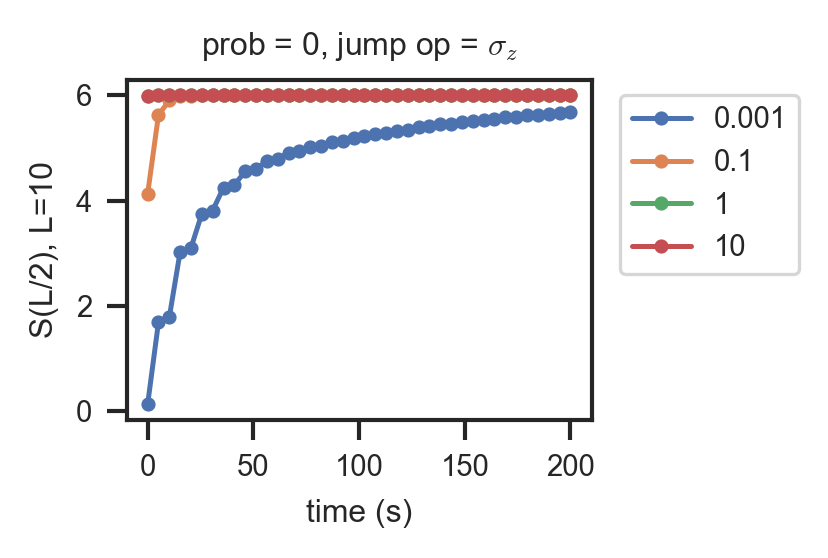

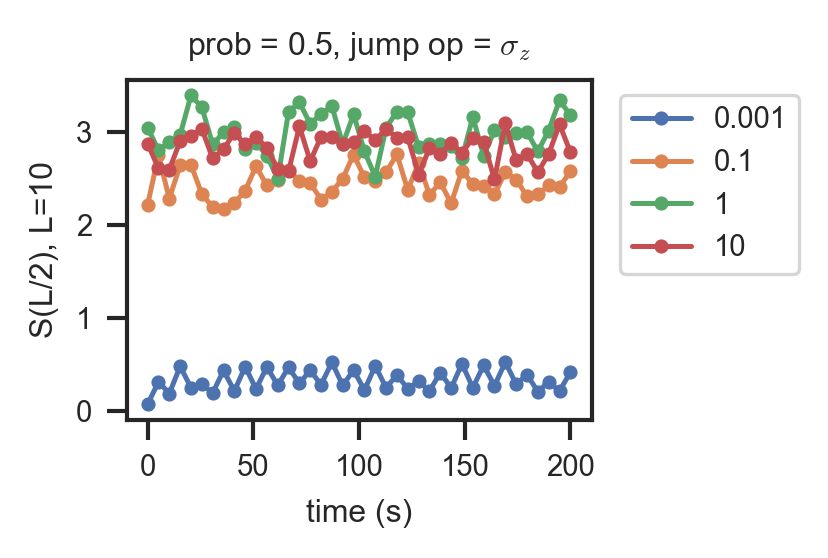

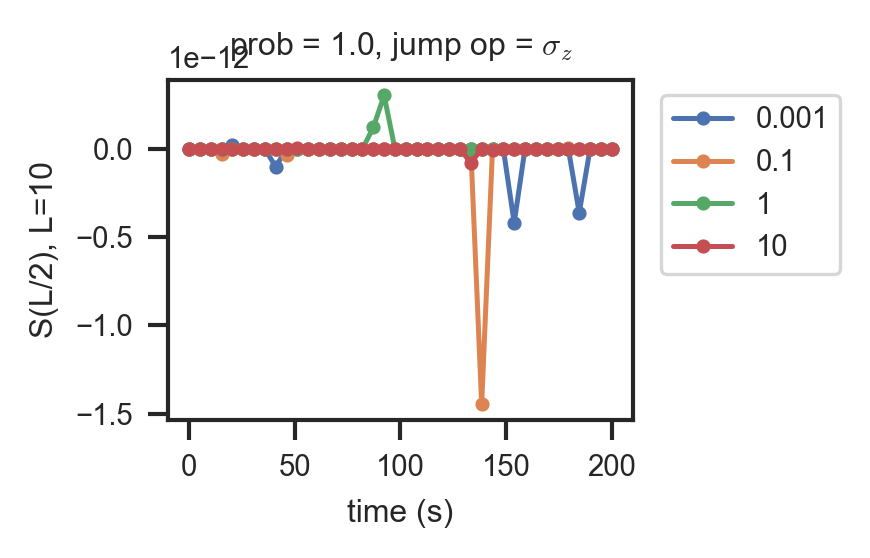

In [8]:
rateList = [1e-03, 1e-01, 1, 10]
t_total = 200
dt = 5
duration = np.linspace(0,t_total,int(t_total/dt))

plt.figure()
for rates in rateList:
    plt.plot(duration, avgedS_dynamics_0[rates][0],'.-')

plt.xlabel('time (s)') 
plt.ylabel('S(L/2), L=10')
plt.title(r'prob = ' + str(0) + ', jump op = $\sigma_z$')
plt.legend(rateList,bbox_to_anchor= (1.03, 1) )



plt.figure()
for rates in rateList:
    plt.plot(duration, avgedS_dynamics_0[rates][0.5],'.-')

plt.xlabel('time (s)') 
plt.ylabel('S(L/2), L=10')
plt.title(r'prob = ' + str(0.5) + ', jump op = $\sigma_z$')
plt.legend(rateList,bbox_to_anchor= (1.03, 1) )


plt.figure()
for rates in rateList:
    plt.plot(duration, avgedS_dynamics_0[rates][1],'.-')

plt.xlabel('time (s)') 
plt.ylabel('S(L/2), L=10')
plt.title(r'prob = ' + str(prob) + ', jump op = $\sigma_z$')
plt.legend(rateList,bbox_to_anchor= (1.03, 1) )



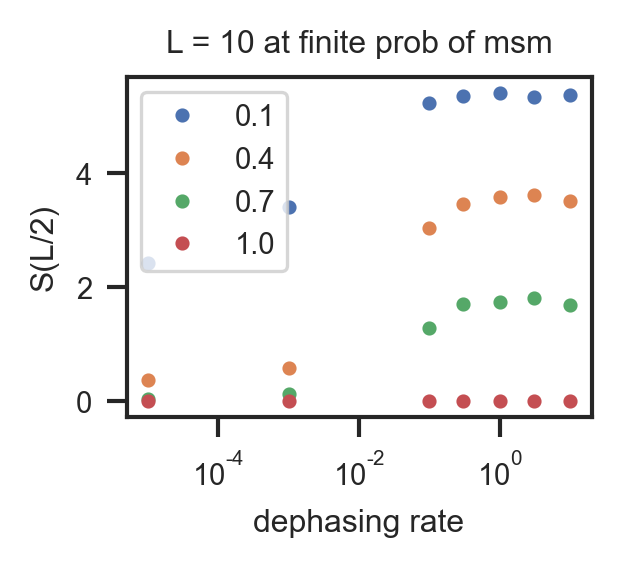

In [10]:
# Extract S(L/2) as a function of the dephasing rate at finite probability of msm
rateList = rateList1 + rateList2
rateList = np.sort(np.array(rateList))

prob = 0.1
probTempList = np.linspace(0.1, 1, 4)

plt.figure()
for prob in probTempList:
    SinRate = np.zeros(len(rateList))
    for (r,rate) in enumerate(rateList):
        SinRate[r] = avgedS_steady_0[rate][prob][-1]

    plt.semilogx(np.array(rateList), SinRate,'.')
    plt.xlabel('dephasing rate')
    plt.ylabel('S(L/2)')
plt.title('L = 10 at finite prob of msm')
plt.legend(probTempList)
print()


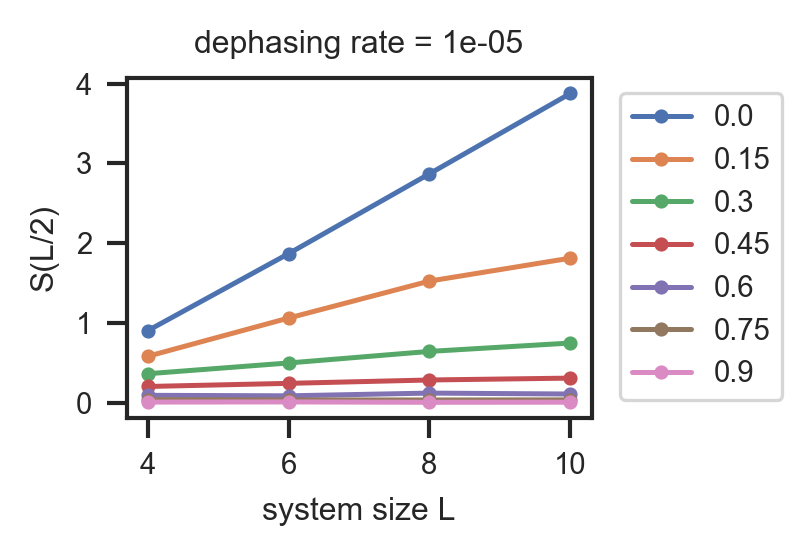

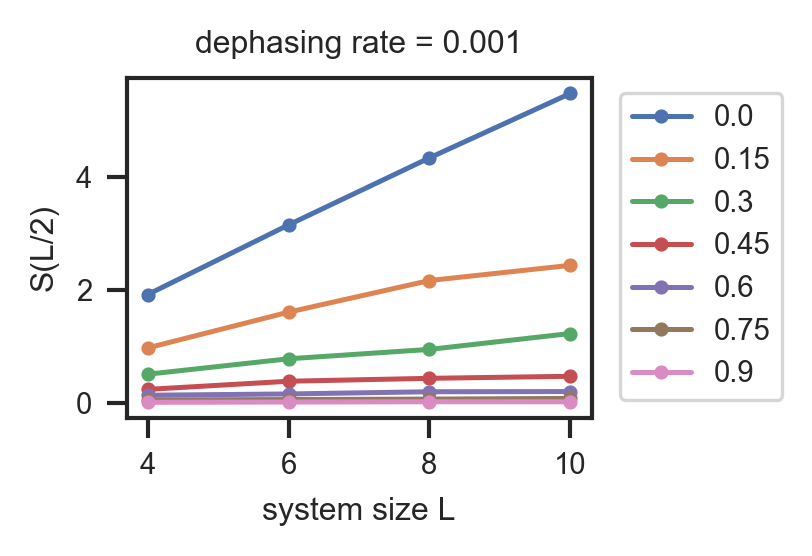

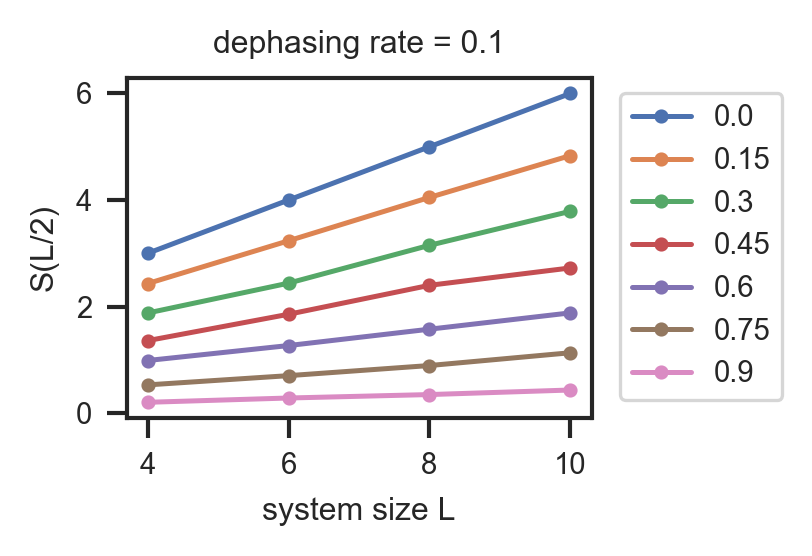

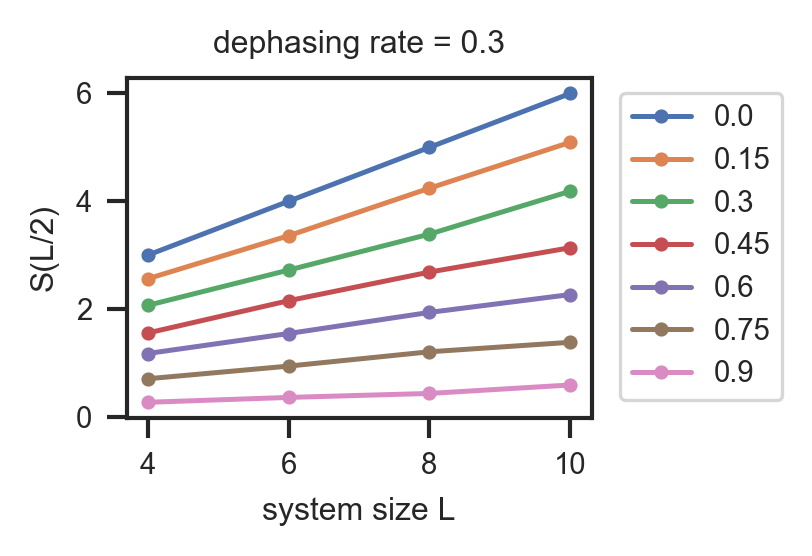

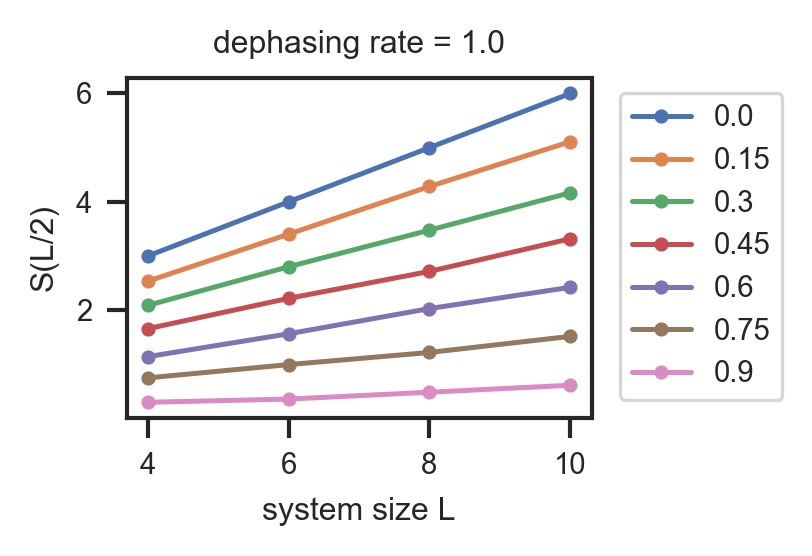

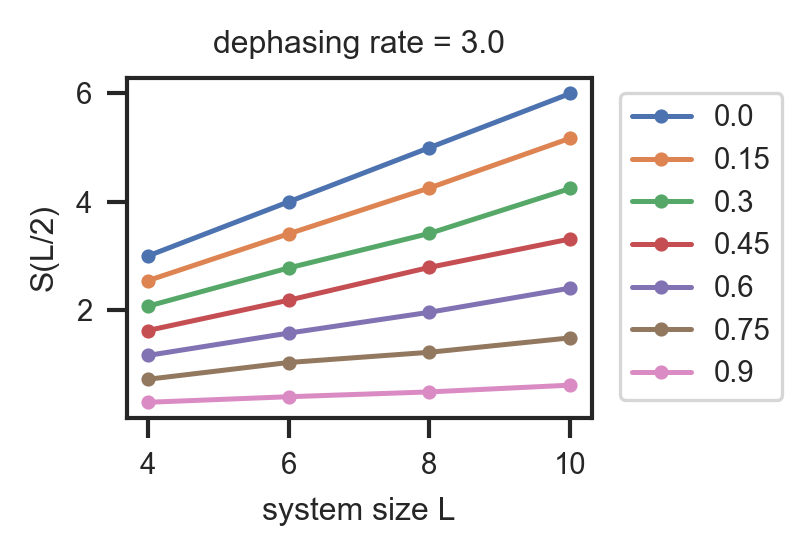

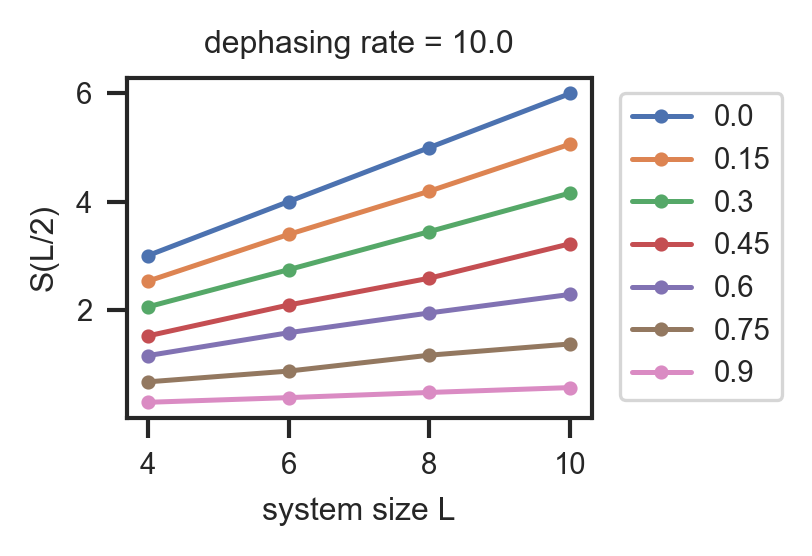

In [11]:
probList = [0.0, 0.15, 0.3, 0.45, 0.6, .75, .9]

for rate in rateList:
    plt.figure()
    for prob in probList:
        plt.plot(np.array(NList), avgedS_steady_0[rate][prob],'.-')
        plt.xlabel('system size L')
        plt.ylabel('S(L/2)')
        plt.title('dephasing rate = ' + str(rate))
        plt.legend(probList,bbox_to_anchor= (1.03, 1))
   

In [10]:
# Let's rename all the files first:
fileList = os.listdir("RC_raw/")
 
for prob in probList:
    for N in NList:
        if os.path.isfile("RC_raw/S1_S_Z_p=" + str(prob) + "_r=10_N=" + str(N) + ".out"):
            os.rename("RC_raw/S1_S_Z_p=" + str(prob) + "_r=10_N=" + str(N) + ".out",
                     "RC_raw/S1_S_Z_p=" + str(prob) + "_r=10.0_N=" + str(N) + ".out")
        
        if os.path.isfile("RC_raw/S1_S_Z_p=" + str(prob) + "_r=1_N=" + str(N) + ".out"):
            os.rename("RC_raw/S1_S_Z_p=" + str(prob) + "_r=1_N=" + str(N) + ".out",
                     "RC_raw/S1_S_Z_p=" + str(prob) + "_r=1.0_N=" + str(N) + ".out")

        if os.path.isfile("RC_raw/I_S_Z_p=" + str(prob) + "_r=10_N=" + str(N) + ".out"):
            os.rename("RC_raw/I_S_Z_p=" + str(prob) + "_r=10_N=" + str(N) + ".out",
                     "RC_raw/I_S_Z_p=" + str(prob) + "_r=10.0_N=" + str(N) + ".out")
        
        if os.path.isfile("RC_raw/I_S_Z_p=" + str(prob) + "_r=1_N=" + str(N) + ".out"):
            os.rename("RC_raw/I_S_Z_p=" + str(prob) + "_r=1_N=" + str(N) + ".out",
                     "RC_raw/I_S_Z_p=" + str(prob) + "_r=1.0_N=" + str(N) + ".out")






In [13]:
rateList = np.logspace(-4,3,8)
probList = np.linspace(0,1,11).round(2)

avgedMI_dynamics_0 = {}
avgedMI_steady_0 = {}

for rate in rateList:
    avgedMI_dynamics_0[rate] = {}
    avgedMI_steady_0[rate] = {}

    for prob in probList: 
        avgedMI_steady_0[rate][prob] = np.zeros(4)
        
        for (n,N) in enumerate(NList): 
            
            if os.path.isfile("RC_raw/I_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out"):
                temp = np.array(np.loadtxt("RC_raw/I_S_Z_p=" + str(prob) + "_r=" + str(rate) + "_N=" + str(N) + ".out") )         
                #print(np.average(temp,axis=0).shape)
                avgedMI_dynamics_0[rate][prob] = np.average(temp,axis=0)
                
                steps = len(temp)//2

                avgedMI_steady_0[rate][prob][n] = np.average(temp[steps:])
            
            #"S1_S_minus_p=0.75_r=0.01_N=10.out"
            else:
                print('missing rate=',rate,', prob=', prob)

                #"S1_S_minus_p=0.75_r=0.01_N=10.out"



missing rate= 0.0001 , prob= 0.0
missing rate= 0.0001 , prob= 0.1
missing rate= 0.0001 , prob= 0.2
missing rate= 0.0001 , prob= 0.3
missing rate= 0.0001 , prob= 0.4
missing rate= 0.0001 , prob= 0.5
missing rate= 0.0001 , prob= 0.6
missing rate= 0.0001 , prob= 0.7
missing rate= 0.0001 , prob= 0.8
missing rate= 0.001 , prob= 0.0
missing rate= 0.001 , prob= 0.1
missing rate= 0.001 , prob= 0.2
missing rate= 0.001 , prob= 0.3
missing rate= 0.001 , prob= 0.4
missing rate= 0.001 , prob= 0.5
missing rate= 0.001 , prob= 0.6
missing rate= 0.001 , prob= 0.7
missing rate= 0.001 , prob= 0.8
missing rate= 0.001 , prob= 0.9
missing rate= 0.001 , prob= 1.0
missing rate= 0.01 , prob= 0.0
missing rate= 0.01 , prob= 0.1
missing rate= 0.01 , prob= 0.6
missing rate= 0.01 , prob= 0.7
missing rate= 0.01 , prob= 0.8
missing rate= 0.01 , prob= 0.9
missing rate= 0.01 , prob= 1.0
missing rate= 0.1 , prob= 0.0
missing rate= 0.1 , prob= 0.1
missing rate= 1.0 , prob= 0.0
missing rate= 1.0 , prob= 0.1
missing rate= 

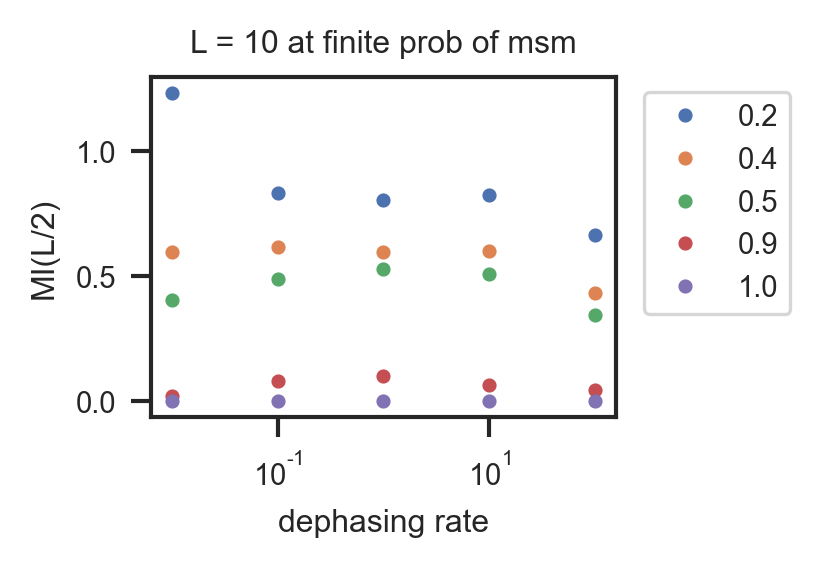

In [16]:
# Extract S(L/2) as a function of the dephasing rate at finite probability of msm

probTempList = [0.2, 0.4, 0.5, 0.9, 1.0]
rateTempList = [0.01,0.1,1.0,10.0,100.0]

plt.figure()
for prob in probTempList:
    MIinRate = np.zeros(len(rateTempList))
    for (r,rate) in enumerate(rateTempList):
        MIinRate[r] = np.average(avgedMI_dynamics_0[rate][prob][-20:])

    plt.semilogx(np.array(rateTempList).astype(float), MIinRate,'.')
    plt.xlabel('dephasing rate')
    plt.ylabel('MI(L/2)')
plt.title('L = 10 at finite prob of msm')
plt.legend(probTempList,bbox_to_anchor= (1.03, 1) )



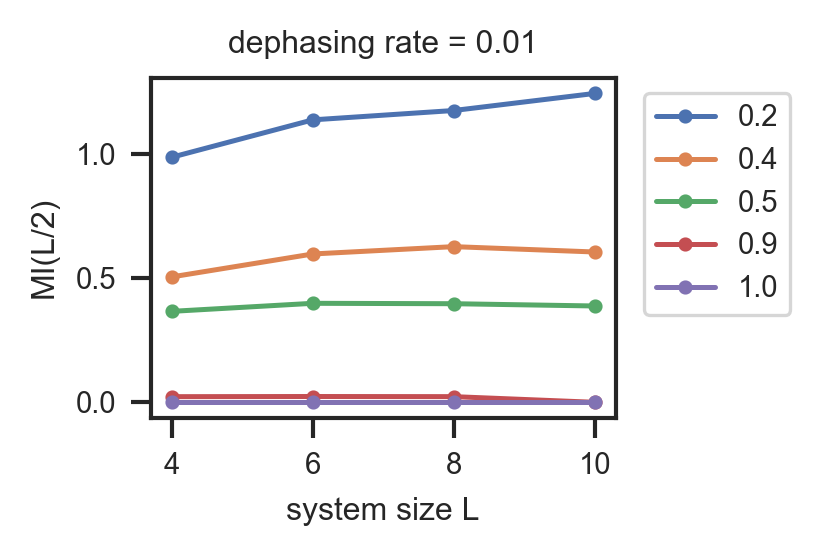

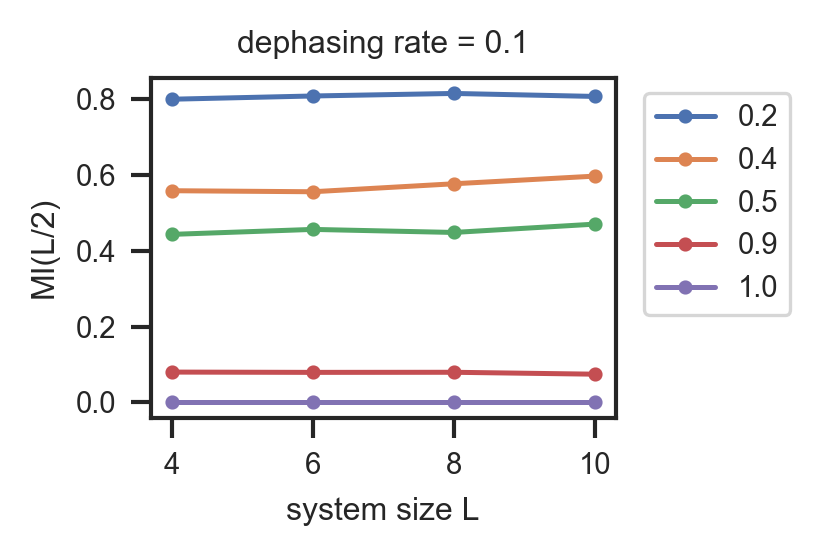

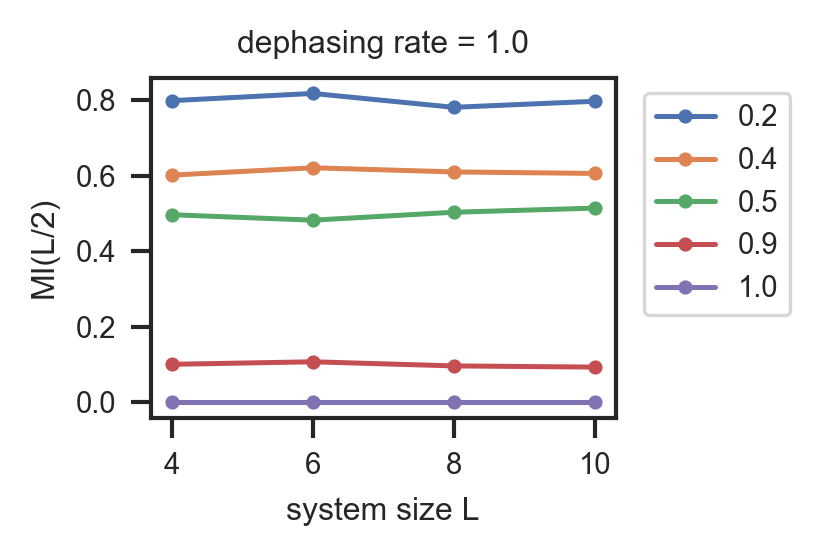

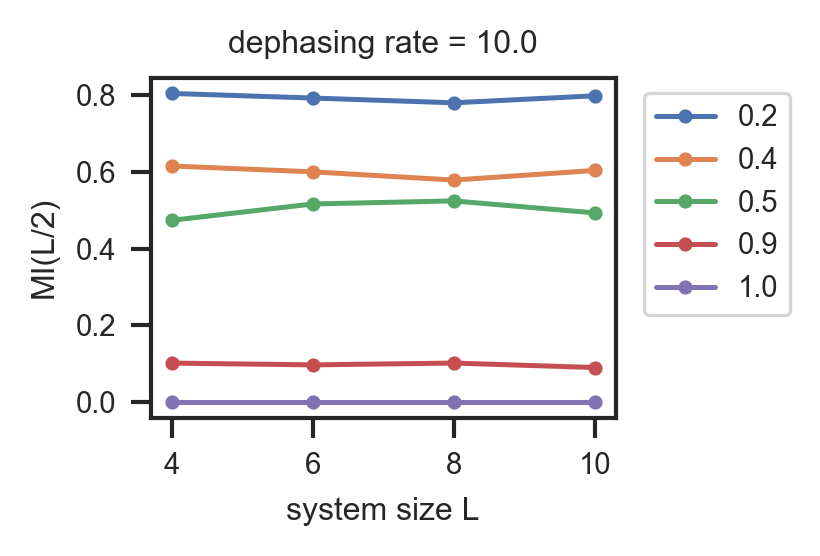

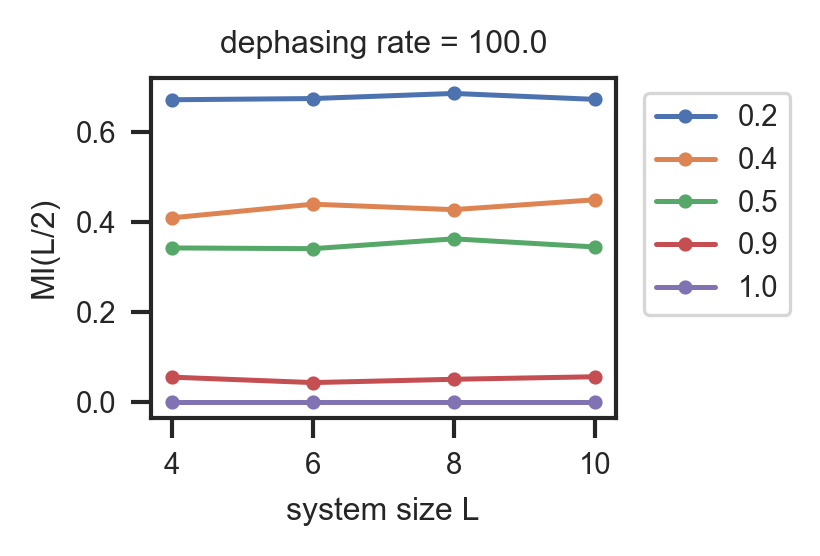

In [19]:
for rate in rateTempList:
    plt.figure()
    for prob in probTempList:
        plt.plot(np.array(NList), avgedMI_steady_0[rate][prob],'.-')
        plt.xlabel('system size L')
        plt.ylabel('MI(L/2)')
        plt.title('dephasing rate = ' + str(rate))
    plt.legend(probTempList,bbox_to_anchor= (1.03, 1))